In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from gluonts.dataset.repository import dataset_recipes

from uni2ts.eval_util.data import get_gluonts_test_dataset
from uni2ts.eval_util.plot import plot_next_multi
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from uni2ts.model.moirai_moe import MoiraiMoEForecast, MoiraiMoEModule
from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module
from uni2ts.model.moiraic import MoiraicForecast, MoiraicModule

import numpy as np

### Settings
SIZE: model size, select the model size of Moirai to perform inference with

CTX: context length, how many time steps the model will take as input for inference

PSZ: patch size, how many time steps to perform patching with

BSZ: batch size, number of samples in each batch for inference

In [2]:
MODEL = "moiraic"  # model name: choose from {'moirai', 'moirai-moe', 'moirai2'}
SIZE = "small"  # model size: choose from {'small', 'base', 'large'}
CTX = 1000  # context length: any positive integer
PSZ = "16"  # patch size: choose from {"auto", 8, 16, 32, 64, 128}
BSZ = 1  # batch size: any positive integer

### Prepare datasets and model

In [3]:
# List of available datasets:
sorted(dataset_recipes.keys())

['ETTh1',
 'ETTh2',
 'ETTm1',
 'ETTm2',
 'METR_LA',
 'airpassengers',
 'australian_electricity_demand',
 'bitcoin',
 'bitcoin_with_missing',
 'car_parts_with_missing',
 'car_parts_without_missing',
 'cif_2016',
 'cif_2016_12',
 'cif_2016_6',
 'constant',
 'covid_deaths',
 'covid_mobility',
 'dominick',
 'elecdemand',
 'electricity',
 'electricity_hourly',
 'electricity_nips',
 'electricity_weekly',
 'ercot',
 'ett_small_15min',
 'ett_small_1h',
 'exchange_rate',
 'exchange_rate_nips',
 'extended_web_traffic_with_missing',
 'fred_md',
 'hospital',
 'istanbul_traffic',
 'jena_weather',
 'kaggle_web_traffic_weekly',
 'kaggle_web_traffic_with_missing',
 'kaggle_web_traffic_without_missing',
 'kdd_cup_2018_with_missing',
 'kdd_cup_2018_without_missing',
 'london_smart_meters_with_missing',
 'london_smart_meters_without_missing',
 'm1_monthly',
 'm1_quarterly',
 'm1_yearly',
 'm3_monthly',
 'm3_other',
 'm3_quarterly',
 'm3_yearly',
 'm4_daily',
 'm4_hourly',
 'm4_monthly',
 'm4_quarterly',


In [4]:
# Load dataset using loader utils
test_data, metadata = get_gluonts_test_dataset(
    "wiki-rolling_nips", prediction_length=None, regenerate=False
)
metadata

MetaData(freq='D', target_dim=1, prediction_length=30, feat_dynamic_real_dim=0, past_feat_dynamic_real_dim=0, split='test')

In [12]:
# Prepare model
if MODEL == "moirai":
    model = MoiraiForecast(
        module=MoiraiModule.from_pretrained(
            f"Salesforce/moirai-1.1-R-{SIZE}",
        ),
        prediction_length=metadata.prediction_length,
        context_length=CTX,
        patch_size=PSZ,
        num_samples=100,
        target_dim=metadata.target_dim,
        feat_dynamic_real_dim=metadata.feat_dynamic_real_dim,
        past_feat_dynamic_real_dim=metadata.past_feat_dynamic_real_dim,
    )
elif MODEL == "moirai-moe":
    model = MoiraiMoEForecast(
        module=MoiraiMoEModule.from_pretrained(
            f"Salesforce/moirai-moe-1.0-R-{SIZE}",
        ),
        prediction_length=metadata.prediction_length,
        context_length=CTX,
        patch_size=16,
        num_samples=100,
        target_dim=metadata.target_dim,
        feat_dynamic_real_dim=metadata.feat_dynamic_real_dim,
        past_feat_dynamic_real_dim=metadata.past_feat_dynamic_real_dim,
    )
elif MODEL == "moirai2":
    model = Moirai2Forecast(
        module=Moirai2Module.from_pretrained(
            f"Salesforce/moirai-2.0-R-small",
        ),
        prediction_length=100,
        context_length=1680,
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=0,
    )
elif MODEL == "moiraic":
    model = MoiraicForecast(
        module=MoiraicModule.from_pretrained(
            f"/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gluonts_wiki/moiraic_gluonts_wiki/HF_checkpoints/last",
        ),
        prediction_length=128,
        context_length=1680,
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=0,
    )

model2 = Moirai2Forecast(
        module=Moirai2Module.from_pretrained(
            f"Salesforce/moirai-2.0-R-small",
        ),
        prediction_length=128,
        context_length=1680,
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=0,
    )

predictor = model.create_predictor(batch_size=BSZ)
forecasts = predictor.predict(test_data.input)

input_it = iter(test_data.input)
label_it = iter(test_data.label)
forecast_it = iter(forecasts)

Loading weights from local directory


### Make predictions

In [16]:
inp = next(input_it)  # input / lookback window
label = next(label_it)  # label / forecast horizon
# forecast = next(forecast_it)  # predictions (GluonTS Forecast object)

In [8]:
inp.keys(), label.keys()

(dict_keys(['target', 'start', 'feat_static_cat', 'item_id']),
 dict_keys(['target', 'start', 'feat_static_cat', 'item_id']))

In [9]:
inp["target"].shape, label["target"].shape

((762,), (30,))

Moirai produces a _probabilistic forecast_, in the form of a mixture distribution.
```forecast``` is a sample forecast, taking ```num_samples=100``` samples from the mixture distribution per time step.

In [10]:
if MODEL == "moirai2" or MODEL == "moiraic":
    print(forecast.mean)
else:
    print(forecast.samples)

NameError: name 'forecast' is not defined

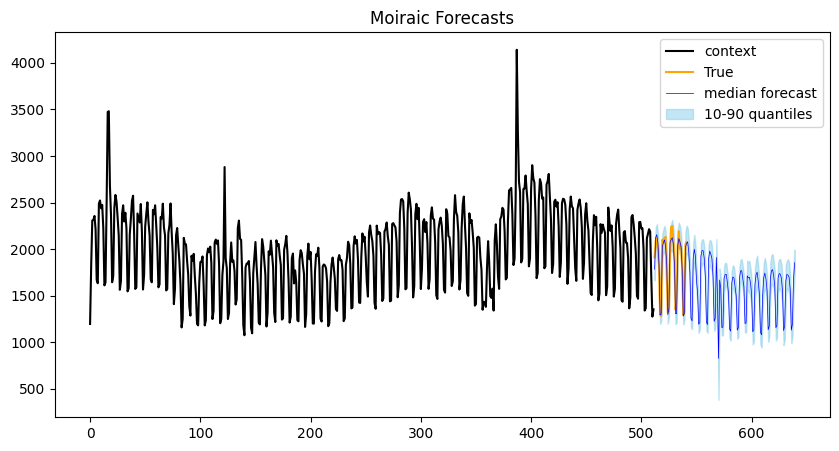

In [17]:
model_pred = model
context_start = 0
context_len = 512
pred_len = 30
obs = np.concatenate([inp["target"], label["target"]])
preds = model_pred.predict(obs[np.newaxis, context_start:context_start+context_len])
plt.figure(figsize=(10,5))
plt.plot(np.arange(context_len), obs[context_start:context_start+context_len], label='context', c='black')
plt.plot(np.arange(pred_len) + context_len, obs[context_start+context_len:context_start+context_len+pred_len], label='True', c='orange')
plt.plot(np.arange(preds.shape[-1]) + context_len, preds[0,4], label='median forecast', c='blue', lw=0.5)
plt.fill_between(np.arange(preds.shape[-1]) + context_len, preds[0,0], preds[0,8], alpha=0.5, color='skyblue', label='10-90 quantiles')
plt.title("Moiraic Forecasts")
plt.legend()
plt.show()

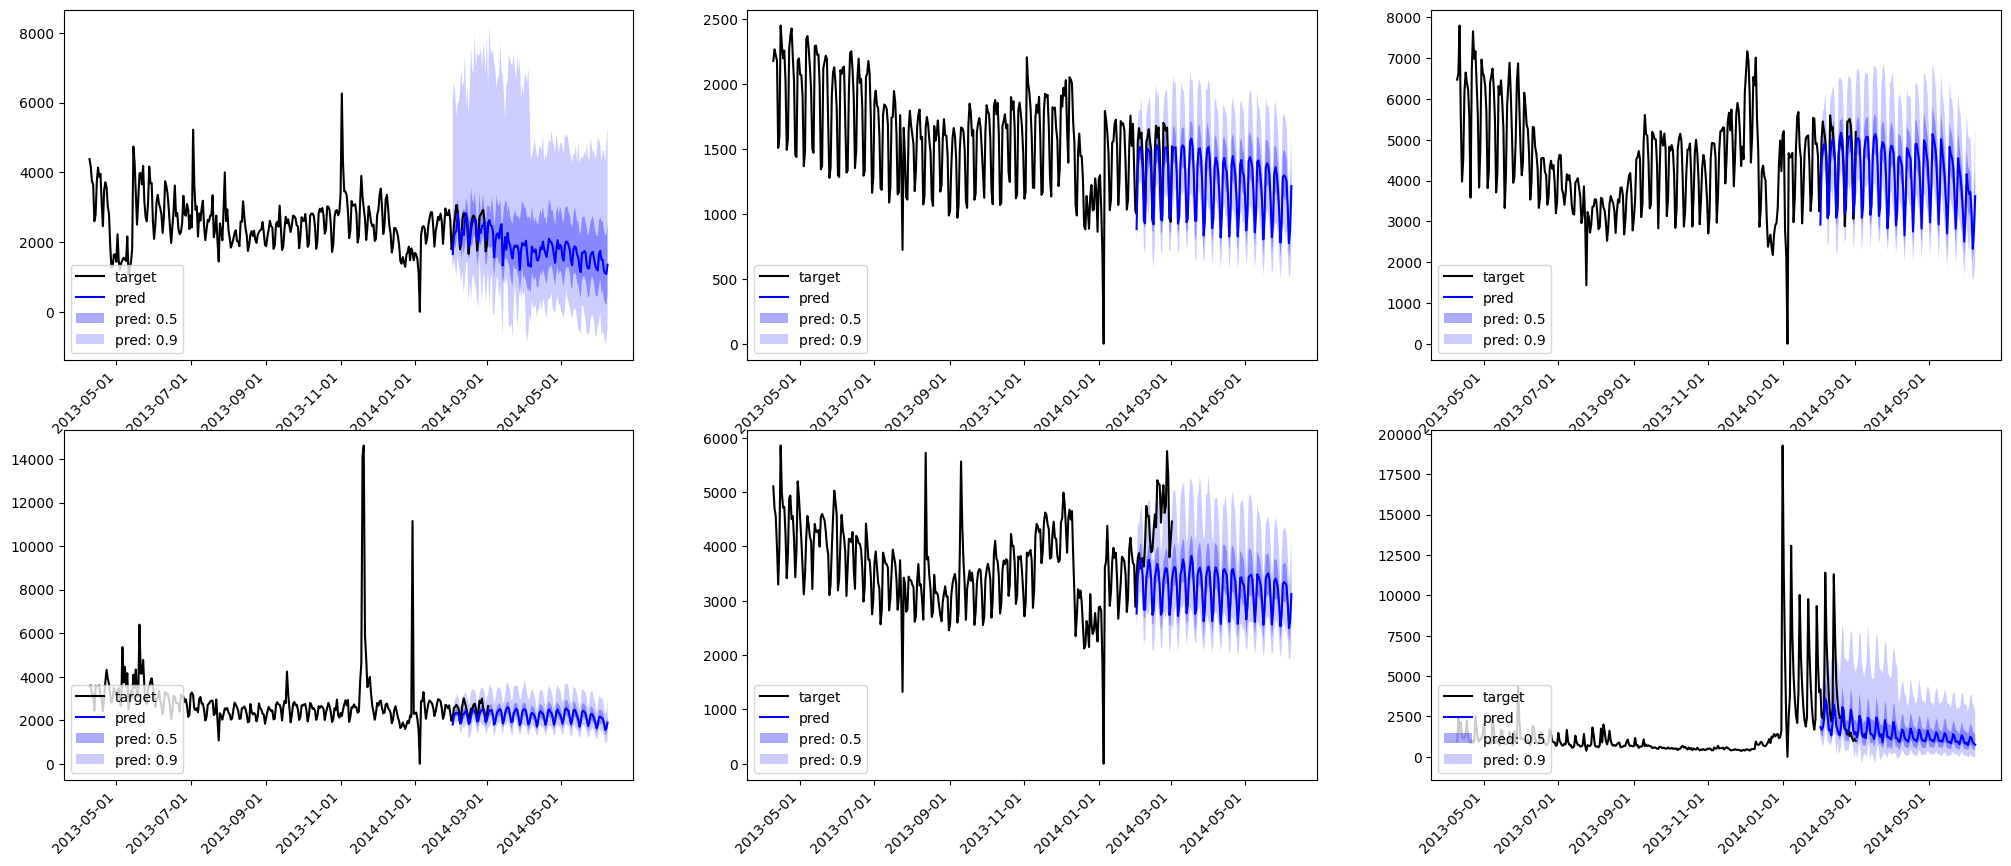

In [ ]:
# Visualize forecasts
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
plot_next_multi(
    axes,
    input_it,
    label_it,
    forecast_it,
    context_length=200,
    intervals=(0.5, 0.9),
    dim=None,
    name="pred",
    show_label=True,
)